# Z24 Bridge Demo Dataset Visualization

This notebook loads and visualizes the Z24 bridge monitoring demo dataset.

**Dataset Info:**
- Source: EMPA/SIMCES Project (Z24 Bridge, Koppigen, Switzerland)
- Demo subset: ~12,000 samples (20 minutes of data)
- 5 accelerometer channels at 10 Hz
- Balanced: 50% healthy / 50% damaged

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from z24_loader import Z24DataLoader

# Plot settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Load Demo Dataset

In [13]:
# Load the demo dataset
DEMO_PATH = '/home/yanni/data/z24/z24_demo_v02.npz'
data = Z24DataLoader.load_demo_dataset(DEMO_PATH)

# Extract components
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
df = data['df']
labels = data['labels']
config = data['config']
scalers = data.get('scalers', {})

print("Demo dataset loaded!")
print(f"\nConfiguration:")
for k, v in config.items():
    print(f"  {k}: {v}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/yanni/data/z24/z24_demo_v02.npz'

## 3. Dataset Overview

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nRaw Data:")
print(f"  Shape: {df.shape}")
print(f"  Channels: {list(df.columns)}")
print(f"  Duration: {len(df) / config['sample_rate_hz'] / 60:.1f} minutes")

print(f"\nLabel Distribution:")
print(f"  Healthy (0): {(labels == 0).sum():,} ({(labels == 0).mean()*100:.1f}%)")
print(f"  Damaged (1): {(labels == 1).sum():,} ({(labels == 1).mean()*100:.1f}%)")

print(f"\nSequence Shapes:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape}")

print(f"\nAnomaly % in Sequences:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pct = (y == 1).sum() / y.size * 100
    print(f"  {name}: {pct:.1f}%")

DATASET OVERVIEW

Raw Data:
  Shape: (200000, 5)
  Channels: ['CH0', 'CH1', 'CH2', 'CH3', 'CH4']
  Duration: 333.3 minutes

Label Distribution:
  Healthy (0): 100,000 (50.0%)
  Damaged (1): 100,000 (50.0%)

Sequence Shapes:
  X_train: (119580, 100, 5) | y_train: (119580, 30, 1)
  X_val:   (39860, 100, 5) | y_val:   (39860, 30, 1)
  X_test:  (39860, 100, 5) | y_test:  (39860, 30, 1)

Anomaly % in Sequences:
  Train: 50.2%
  Val: 50.0%
  Test: 50.0%


## 4. Raw Sensor Time Series

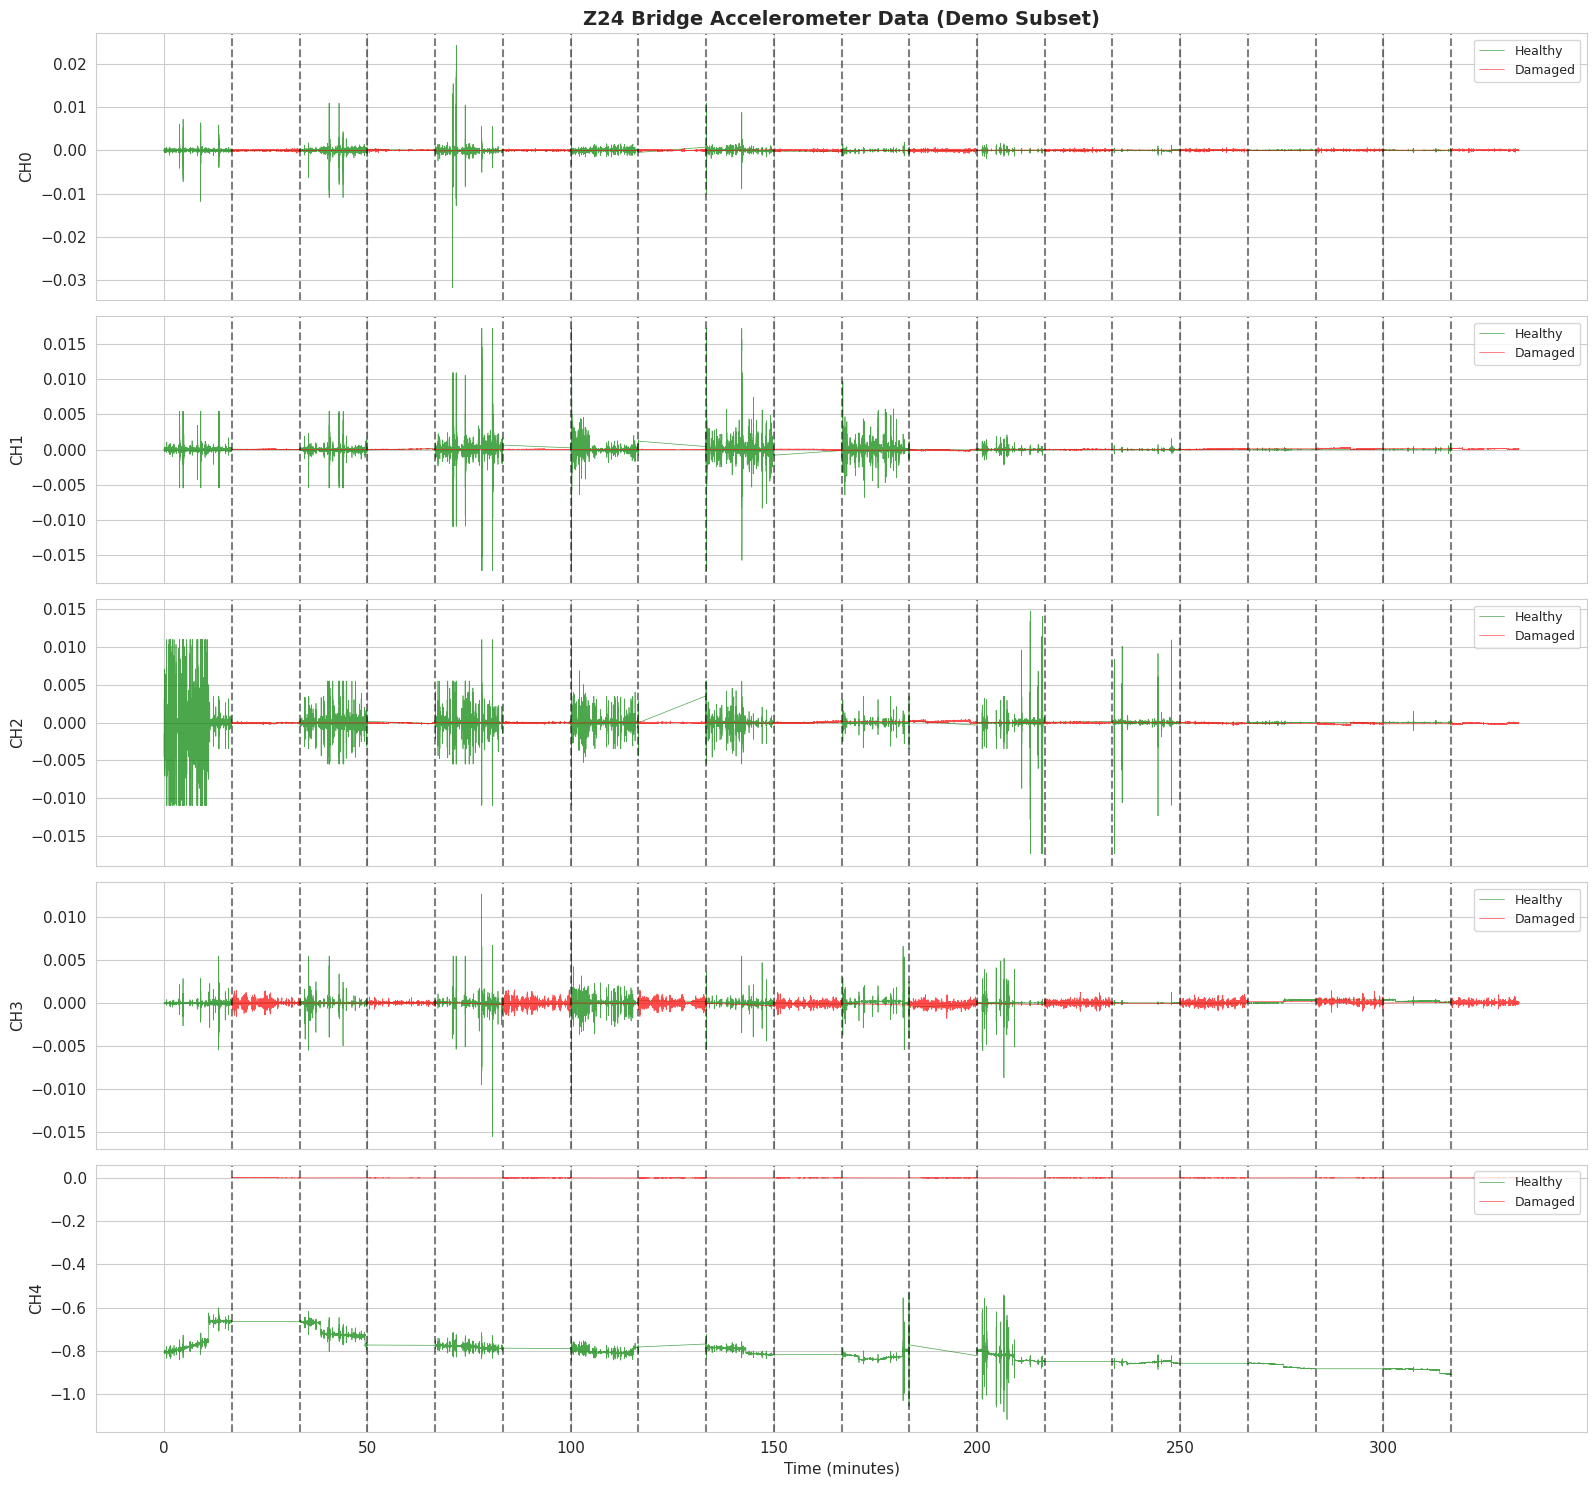

In [4]:
# Plot all channels over time
fig, axes = plt.subplots(len(df.columns), 1, figsize=(16, 3*len(df.columns)), sharex=True)

time_sec = np.arange(len(df)) / config['sample_rate_hz']
time_min = time_sec / 60

# Find transition point
transition_idx = np.where(np.diff(labels.values) != 0)[0]

for i, col in enumerate(df.columns):
    ax = axes[i]
    
    # Plot healthy in green, damaged in red
    healthy_mask = labels.values == 0
    damaged_mask = labels.values == 1
    
    ax.plot(time_min[healthy_mask], df[col].values[healthy_mask], 
            'g-', alpha=0.7, linewidth=0.5, label='Healthy')
    ax.plot(time_min[damaged_mask], df[col].values[damaged_mask], 
            'r-', alpha=0.7, linewidth=0.5, label='Damaged')
    
    # Mark transitions
    for idx in transition_idx:
        ax.axvline(x=time_min[idx], color='black', linestyle='--', alpha=0.5)
    
    ax.set_ylabel(col)
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (minutes)')
axes[0].set_title('Z24 Bridge Accelerometer Data (Demo Subset)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Statistical Comparison: Healthy vs Damaged

In [5]:
# Compute statistics for healthy vs damaged
healthy_data = df[labels.values == 0]
damaged_data = df[labels.values == 1]

stats = []
for col in df.columns:
    stats.append({
        'Channel': col,
        'Healthy Mean': healthy_data[col].mean(),
        'Healthy Std': healthy_data[col].std(),
        'Damaged Mean': damaged_data[col].mean(),
        'Damaged Std': damaged_data[col].std(),
        'Mean Diff %': (damaged_data[col].mean() - healthy_data[col].mean()) / (healthy_data[col].std() + 1e-10) * 100
    })

stats_df = pd.DataFrame(stats)
print("Statistical Comparison (Healthy vs Damaged):")
print(stats_df.to_string(index=False))

Statistical Comparison (Healthy vs Damaged):
Channel  Healthy Mean  Healthy Std  Damaged Mean  Damaged Std  Mean Diff %
    CH0      0.000011     0.000488      0.000025     0.000069     2.907382
    CH1      0.000020     0.000897      0.000032     0.000067     1.297941
    CH2     -0.000021     0.000986     -0.000043     0.000098    -2.232401
    CH3      0.000065     0.000273     -0.000007     0.000210   -26.481050
    CH4     -0.808814     0.057809      0.000023     0.000319  1399.164220


/tmp/ipykernel_7480/2693379255.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Healthy', 'Damaged'], patch_artist=True)
/tmp/ipykernel_7480/2693379255.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Healthy', 'Damaged'], patch_artist=True)
/tmp/ipykernel_7480/2693379255.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Healthy', 'Damaged'], patch_artist=True)
/tmp/ipykernel_7480/2693379255.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matp

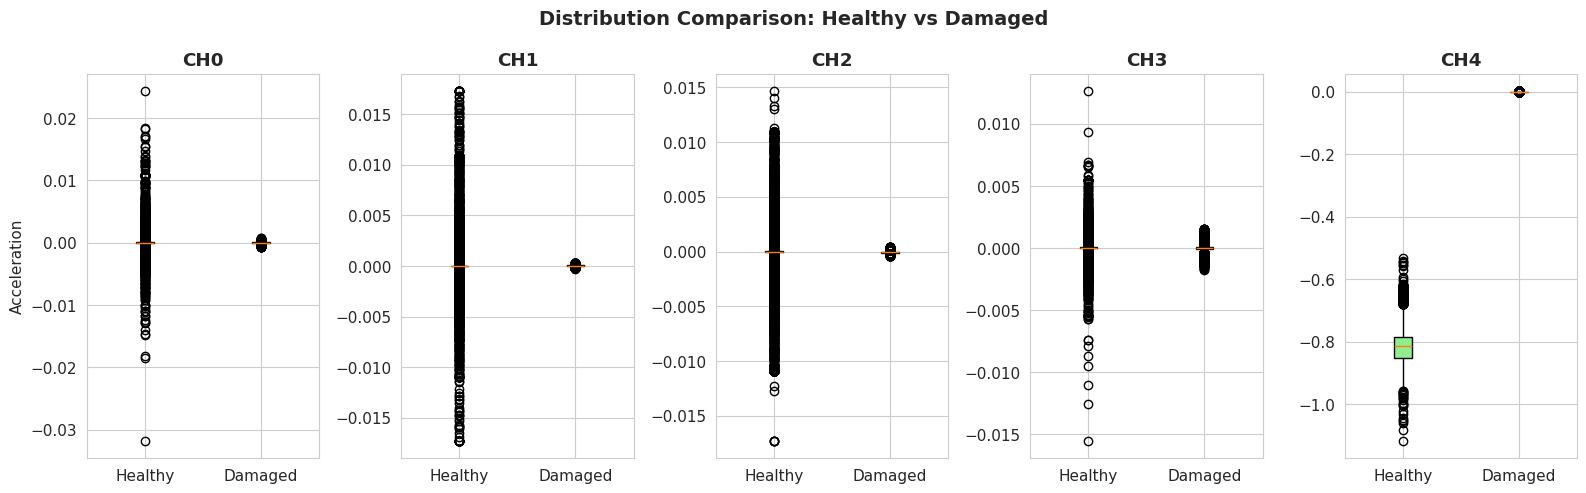

In [6]:
# Box plots comparing distributions
fig, axes = plt.subplots(1, len(df.columns), figsize=(16, 5))

for i, col in enumerate(df.columns):
    ax = axes[i]
    
    box_data = [
        healthy_data[col].values,
        damaged_data[col].values
    ]
    
    bp = ax.boxplot(box_data, labels=['Healthy', 'Damaged'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Acceleration' if i == 0 else '')

plt.suptitle('Distribution Comparison: Healthy vs Damaged', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Frequency Domain Analysis

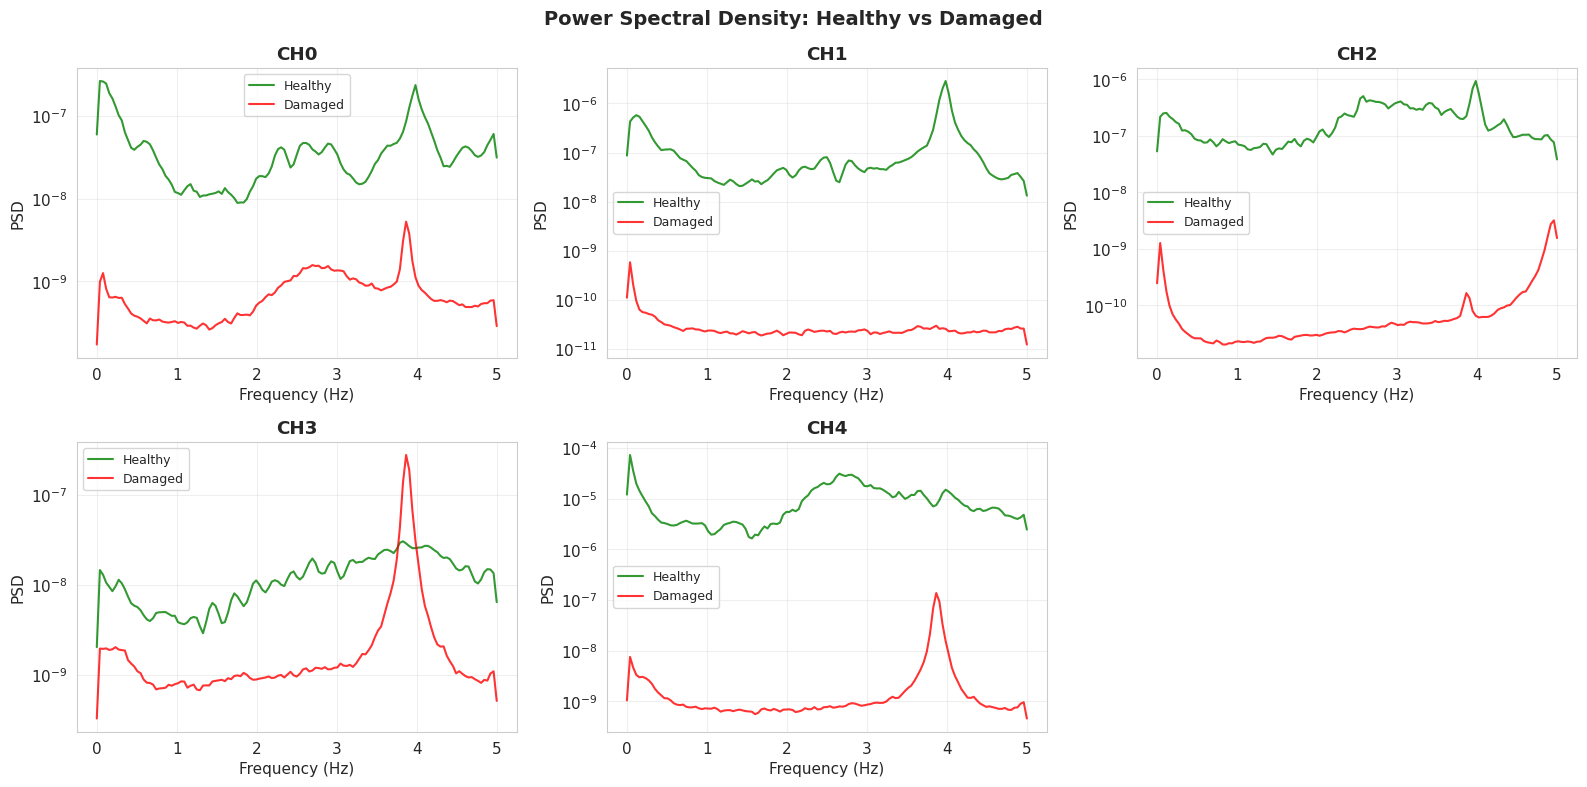

In [7]:
from scipy import signal

# Compute Power Spectral Density for healthy vs damaged
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

fs = config['sample_rate_hz']  # Sampling frequency

for i, col in enumerate(df.columns):
    ax = axes[i]
    
    # Healthy PSD
    f_h, psd_h = signal.welch(healthy_data[col].values, fs=fs, nperseg=256)
    ax.semilogy(f_h, psd_h, 'g-', label='Healthy', alpha=0.8)
    
    # Damaged PSD
    f_d, psd_d = signal.welch(damaged_data[col].values, fs=fs, nperseg=256)
    ax.semilogy(f_d, psd_d, 'r-', label='Damaged', alpha=0.8)
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[-1].axis('off')

plt.suptitle('Power Spectral Density: Healthy vs Damaged', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

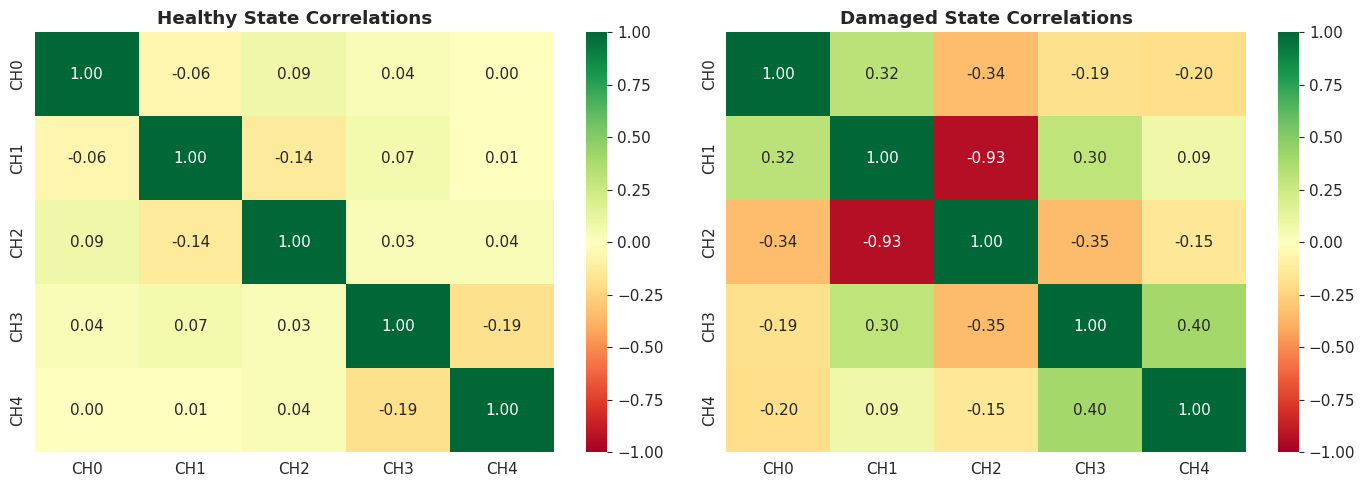


Correlation Change (Damaged - Healthy):
       CH0    CH1    CH2    CH3    CH4
CH0  0.000  0.382 -0.426 -0.227 -0.202
CH1  0.382  0.000 -0.793  0.230  0.087
CH2 -0.426 -0.793  0.000 -0.380 -0.189
CH3 -0.227  0.230 -0.380  0.000  0.588
CH4 -0.202  0.087 -0.189  0.588  0.000


In [8]:
# Correlation heatmaps for healthy vs damaged
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Healthy correlation
corr_healthy = healthy_data.corr()
sns.heatmap(corr_healthy, annot=True, cmap='RdYlGn', center=0, 
            ax=axes[0], vmin=-1, vmax=1, fmt='.2f')
axes[0].set_title('Healthy State Correlations', fontweight='bold')

# Damaged correlation
corr_damaged = damaged_data.corr()
sns.heatmap(corr_damaged, annot=True, cmap='RdYlGn', center=0, 
            ax=axes[1], vmin=-1, vmax=1, fmt='.2f')
axes[1].set_title('Damaged State Correlations', fontweight='bold')

plt.tight_layout()
plt.show()

# Show correlation difference
print("\nCorrelation Change (Damaged - Healthy):")
corr_diff = corr_damaged - corr_healthy
print(corr_diff.round(3))

## 8. Sequence Visualization (Model Input/Output)

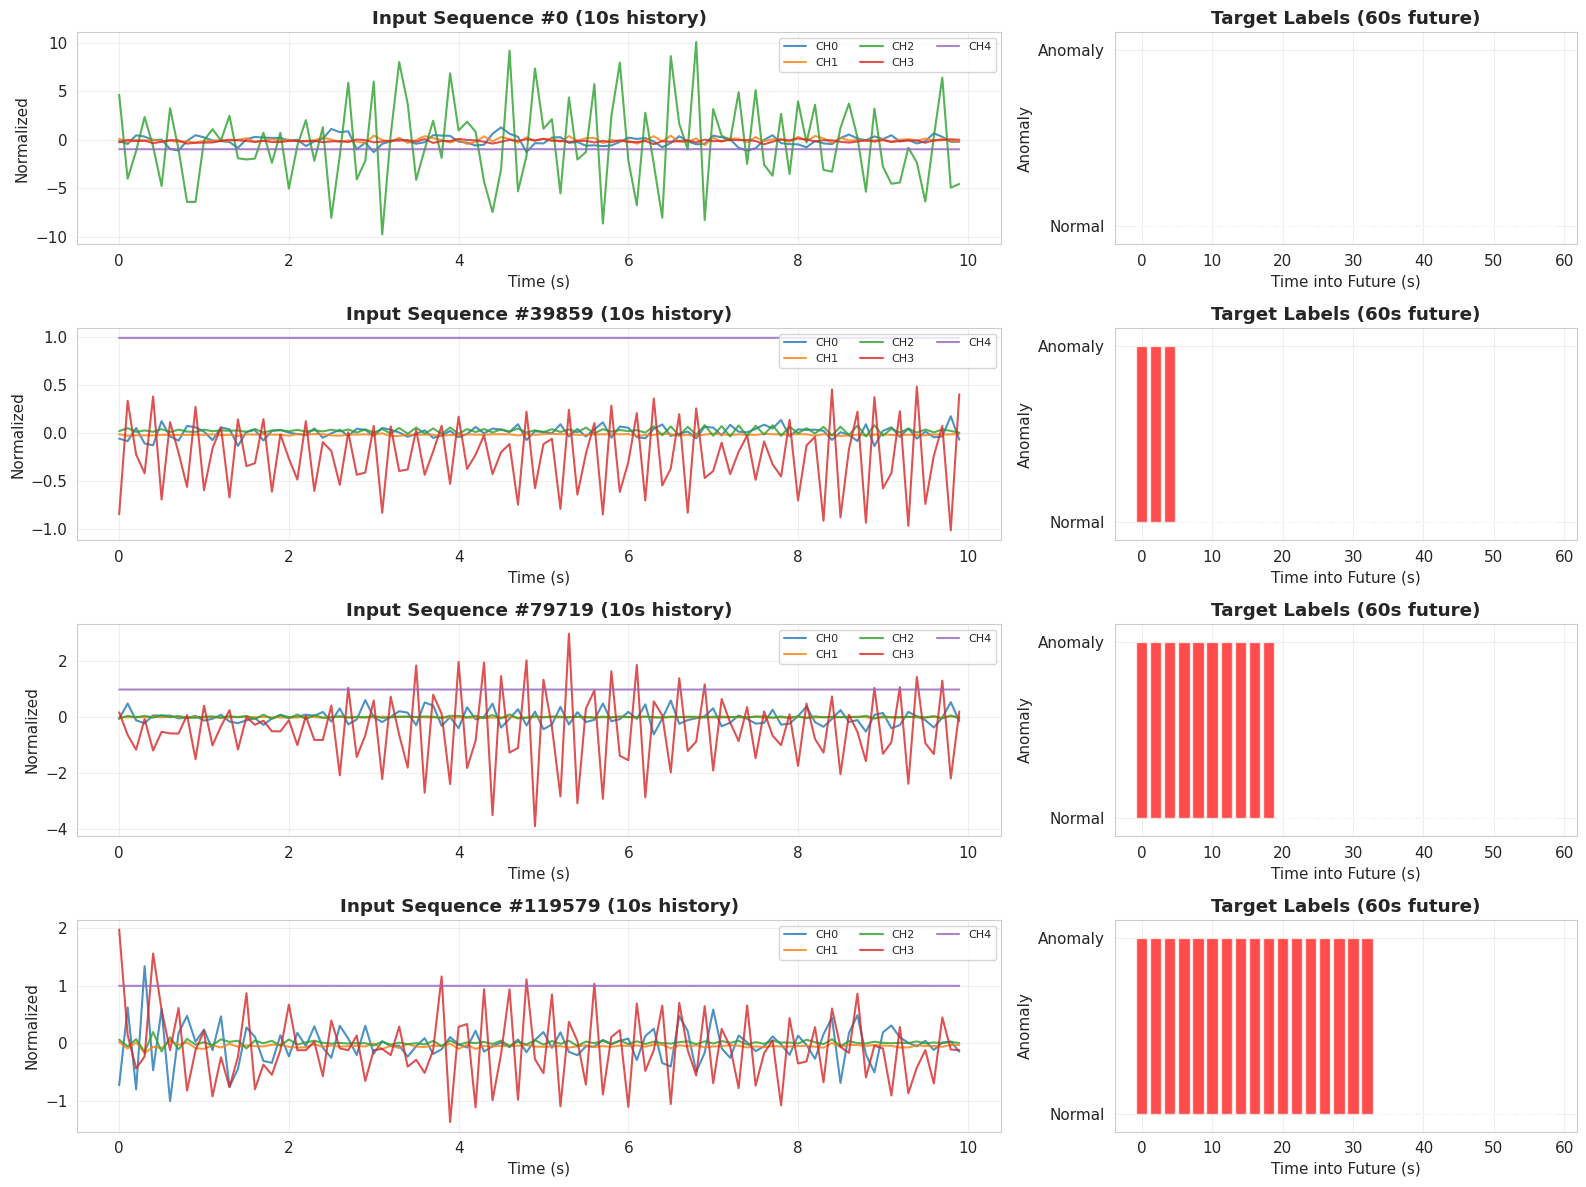

In [9]:
# Visualize sample sequences from training data
n_samples = 4
fig, axes = plt.subplots(n_samples, 2, figsize=(16, 3*n_samples),
                         gridspec_kw={'width_ratios': [2, 1]})

# Select diverse samples
sample_indices = np.linspace(0, len(X_train)-1, n_samples, dtype=int)

time_input = np.arange(config['input_steps']) / config['sample_rate_hz']
time_output = np.arange(config['n_output_steps']) * (config['output_sample_rate'] / config['sample_rate_hz'])

for i, idx in enumerate(sample_indices):
    # Input sequence (all channels)
    ax_in = axes[i, 0]
    for j, ch in enumerate(config['channels']):
        ax_in.plot(time_input, X_train[idx, :, j], label=ch, alpha=0.8)
    ax_in.set_xlabel('Time (s)')
    ax_in.set_ylabel('Normalized')
    ax_in.set_title(f'Input Sequence #{idx} (10s history)', fontweight='bold')
    ax_in.legend(loc='upper right', fontsize=8, ncol=3)
    ax_in.grid(True, alpha=0.3)
    
    # Output sequence (anomaly labels)
    ax_out = axes[i, 1]
    colors = ['green' if v == 0 else 'red' for v in y_train[idx, :, 0]]
    ax_out.bar(time_output, y_train[idx, :, 0], 
               width=config['output_sample_rate']/config['sample_rate_hz']*0.8,
               color=colors, alpha=0.7)
    ax_out.set_xlabel('Time into Future (s)')
    ax_out.set_ylabel('Anomaly')
    ax_out.set_title(f'Target Labels (60s future)', fontweight='bold')
    ax_out.set_ylim(-0.1, 1.1)
    ax_out.set_yticks([0, 1])
    ax_out.set_yticklabels(['Normal', 'Anomaly'])
    ax_out.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Label Transition Analysis

In [10]:
# Analyze how labels transition in sequences
def analyze_sequences(y):
    """Analyze anomaly patterns in output sequences."""
    n_seqs = len(y)
    
    # Sequence-level stats
    all_healthy = (y.sum(axis=(1,2)) == 0).sum()
    all_anomaly = (y.sum(axis=(1,2)) == y.shape[1]).sum()
    mixed = n_seqs - all_healthy - all_anomaly
    
    # First anomaly position in mixed sequences
    first_anomaly_positions = []
    for i in range(n_seqs):
        anomaly_idx = np.where(y[i, :, 0] == 1)[0]
        if len(anomaly_idx) > 0 and len(anomaly_idx) < y.shape[1]:
            first_anomaly_positions.append(anomaly_idx[0])
    
    return {
        'total': n_seqs,
        'all_healthy': all_healthy,
        'all_anomaly': all_anomaly,
        'mixed': mixed,
        'first_anomaly_positions': first_anomaly_positions
    }

print("Sequence Label Analysis:")
print("=" * 50)
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    stats = analyze_sequences(y)
    print(f"\n{name}:")
    print(f"  All healthy:  {stats['all_healthy']:3d} ({stats['all_healthy']/stats['total']*100:.1f}%)")
    print(f"  All anomaly:  {stats['all_anomaly']:3d} ({stats['all_anomaly']/stats['total']*100:.1f}%)")
    print(f"  Mixed:        {stats['mixed']:3d} ({stats['mixed']/stats['total']*100:.1f}%)")

Sequence Label Analysis:



Train:
  All healthy:  56306 (47.1%)
  All anomaly:  56634 (47.4%)
  Mixed:        6640 (5.6%)

Val:
  All healthy:  18802 (47.2%)
  All anomaly:  18878 (47.4%)
  Mixed:        2180 (5.5%)

Test:
  All healthy:  18802 (47.2%)
  All anomaly:  18858 (47.3%)
  Mixed:        2200 (5.5%)


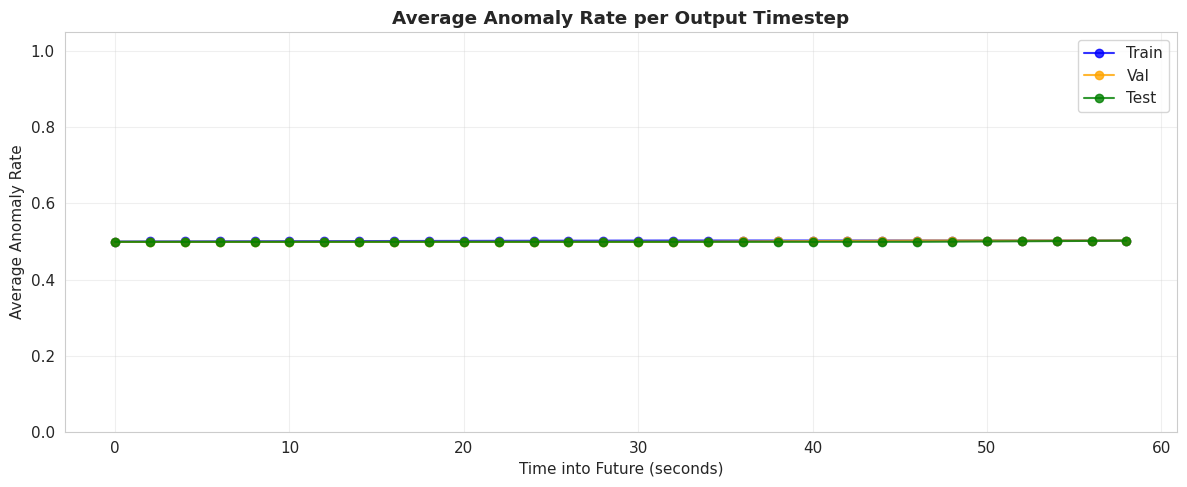

In [11]:
# Visualize average anomaly probability per output timestep
fig, ax = plt.subplots(figsize=(12, 5))

time_output = np.arange(config['n_output_steps']) * (config['output_sample_rate'] / config['sample_rate_hz'])

for name, y, color in [('Train', y_train, 'blue'), ('Val', y_val, 'orange'), ('Test', y_test, 'green')]:
    avg_anomaly = y.mean(axis=0).flatten()
    ax.plot(time_output, avg_anomaly, '-o', label=f'{name}', color=color, alpha=0.8)

ax.set_xlabel('Time into Future (seconds)')
ax.set_ylabel('Average Anomaly Rate')
ax.set_title('Average Anomaly Rate per Output Timestep', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 10. Summary

In [12]:
print("=" * 60)
print("Z24 DEMO DATASET SUMMARY")
print("=" * 60)
print(f"""
Dataset: Z24 Bridge Progressive Damage Tests (Demo Subset)

Raw Data:
  - {len(df):,} samples ({len(df)/config['sample_rate_hz']/60:.1f} minutes)
  - {len(df.columns)} accelerometer channels
  - {config['sample_rate_hz']} Hz sampling rate
  - 50% healthy / 50% damaged (balanced)

Model-Ready Sequences:
  - Input:  {config['input_steps']} timesteps ({config['input_steps']/config['sample_rate_hz']:.0f}s history)
  - Output: {config['n_output_steps']} risk scores ({config['output_steps']/config['sample_rate_hz']:.0f}s horizon)
  - Train:  {len(X_train)} sequences
  - Val:    {len(X_val)} sequences  
  - Test:   {len(X_test)} sequences

Ready for CNN-LSTM Encoder-Decoder training!
""")
print("=" * 60)

Z24 DEMO DATASET SUMMARY

Dataset: Z24 Bridge Progressive Damage Tests (Demo Subset)

Raw Data:
  - 200,000 samples (333.3 minutes)
  - 5 accelerometer channels
  - 10 Hz sampling rate
  - 50% healthy / 50% damaged (balanced)

Model-Ready Sequences:
  - Input:  100 timesteps (10s history)
  - Output: 30 risk scores (60s horizon)
  - Train:  119580 sequences
  - Val:    39860 sequences  
  - Test:   39860 sequences

Ready for CNN-LSTM Encoder-Decoder training!

